# 05b — Qualitative error tagging (Week 5 Phase 2)

Phase 1 (`05a`) localised *where* the models fail. Phase 2 explains *why*
by hand-tagging a stratified sample of ~100 failure cases with 8 error
categories, then quantifying which categories dominate which failure modes.

**Phase-1 findings this notebook tests:**

* F2 — OFFENSIVE F1 crashes 0.60 → 0.03 as length grows (long-context).
* F5 — OFFENSIVE→CLEAN failures have stopword-y top words → subtle toxicity
  with no explicit toxic vocab (`no_toxic_vocab`).
* F7 — universal failures (subset D) are 56% toxic vs 17% base rate.

**Tagging schema (8 categories):**

| Category | Definition |
|---|---|
| `sarcasm`             | surface-positive / intended-negative, irony |
| `code_switching`      | mixes English + Vietnamese (esp. slurs) |
| `teen_code`           | `vcl`, `vl`, `dm`, leetspeak, spacing tricks, obfuscation |
| `implicit_contextual` | toxic only given target / world knowledge, no explicit slur |
| `annotation_doubt`    | the gold label looks wrong or genuinely borderline |
| `very_short`          | ≤ 3 tokens (auto-prefilled) |
| `long_context`        | > 30 tokens (auto-prefilled) |
| `no_toxic_vocab`      | true label is toxic but text has no explicit profanity |

**Workflow**: Part A builds the pool → Part B is the interactive tagger
(run, click through ~100 cases, auto-saves every 10) → Part C analyses the
tags once you're done. Tagging is ~2 min/case; split across 2-3 sessions —
progress is saved to `results/manual_tagging_progress.csv` and resumes
automatically.

**Outputs:**

* `results/manual_tagging_pool.csv`        — the 100 sampled cases (blank tags)
* `results/manual_tagging_progress.csv`    — your in-progress / final tags
* `report/error_categories_examples.md`    — representative examples per category
* `report/week5_qualitative_findings.md`   — Part-C synthesis


In [1]:
# ── Setup ──────────────────────────────────────────────────────────────
%load_ext autoreload
%autoreload 2

import sys
for _k in [k for k in sys.modules if k == "src" or k.startswith("src.")]:
    del sys.modules[_k]

import json
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path = [str(ROOT)] + [p for p in sys.path if p != str(ROOT)]

from configs.config import LABEL_MAP

RESULTS_DIR = ROOT / "results"
REPORT_DIR  = ROOT / "report"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

CATEGORIES = [
    "sarcasm", "code_switching", "teen_code", "implicit_contextual",
    "annotation_doubt", "very_short", "long_context", "no_toxic_vocab",
]
AUTO_CATEGORIES = ["very_short", "long_context"]   # deterministic from length
print("Setup done. 8 tagging categories defined.")


Setup done. 8 tagging categories defined.


## A. Stratified sampling — 100 cases

All five strata are derived from `results/test_master_predictions.csv`
(the joined frame from `05a`) so the sampling is guaranteed row-aligned and
de-duplicated. Strata are filled in priority order (D first — universal
failures are the most informative), and a case already picked by a
higher-priority stratum won't be double-counted.

In [2]:
master = pd.read_csv(RESULTS_DIR / "test_master_predictions.csv")
# Re-derive correctness (don't trust CSV bool parsing across pandas versions).
master["lr_correct"]      = master["lr_pred"]      == master["true_label"]
master["bilstm_correct"]  = master["bilstm_pred"]  == master["true_label"]
master["phobert_correct"] = master["phobert_pred"] == master["true_label"]
master["test_idx"] = np.arange(len(master))

strata_masks = {
    "D_all_wrong":            (~master["lr_correct"]) & (~master["bilstm_correct"]) & (~master["phobert_correct"]),
    "A_LRright_PhoBERTwrong": master["lr_correct"] & (~master["phobert_correct"]),
    "B_PhoBERTright_LRwrong": master["phobert_correct"] & (~master["lr_correct"]),
    "high_conf_wrong":        (master["phobert_conf"] > 0.8) & (~master["phobert_correct"]),
    "off_long":               (master["true_label"] == 1) & (master["length"] > 30),
}
strata_quota = {
    "D_all_wrong": 30, "A_LRright_PhoBERTwrong": 20, "B_PhoBERTright_LRwrong": 20,
    "high_conf_wrong": 20, "off_long": 10,
}
priority = ["D_all_wrong", "A_LRright_PhoBERTwrong", "B_PhoBERTright_LRwrong",
            "high_conf_wrong", "off_long"]

picked, rows = set(), []
for name in priority:
    avail = master[strata_masks[name] & (~master["test_idx"].isin(picked))]
    k = min(strata_quota[name], len(avail))
    samp = avail.sample(k, random_state=RANDOM_STATE) if k else avail
    for _, r in samp.iterrows():
        picked.add(int(r["test_idx"]))
        rows.append({
            "source_subset":      name,
            "test_idx":           int(r["test_idx"]),
            "text":               r["text"],
            "length":             int(r["length"]),
            "true_label":         int(r["true_label"]),
            "true_name":          LABEL_MAP[int(r["true_label"])],
            "lr_pred":            int(r["lr_pred"]),
            "bilstm_pred":        int(r["bilstm_pred"]),
            "phobert_pred":       int(r["phobert_pred"]),
            "phobert_confidence": float(r["phobert_conf"]),
        })
    print(f"  {name:<26s}: requested {strata_quota[name]:>2d}, took {k:>2d}")

pool = pd.DataFrame(rows).reset_index(drop=True)
pool.insert(0, "sample_id", np.arange(len(pool)))

# Blank tagging columns (+ auto-prefill the two deterministic ones).
for c in CATEGORIES:
    pool[c] = 0
pool.loc[pool["length"] <= 3,  "very_short"]   = 1
pool.loc[pool["length"] > 30,  "long_context"] = 1
pool["notes"] = ""

pool_path = RESULTS_DIR / "manual_tagging_pool.csv"
pool.to_csv(pool_path, index=False)
print(f"\n✓ pool: {len(pool)} unique cases → {pool_path}")
print(f"  source breakdown: {pool['source_subset'].value_counts().to_dict()}")
print(f"  true-class breakdown: {pool['true_name'].value_counts().to_dict()}")
print(f"  auto-prefilled: very_short={int(pool['very_short'].sum())}, long_context={int(pool['long_context'].sum())}")


  D_all_wrong               : requested 30, took 30
  A_LRright_PhoBERTwrong    : requested 20, took 20
  B_PhoBERTright_LRwrong    : requested 20, took 20
  high_conf_wrong           : requested 20, took 20
  off_long                  : requested 10, took 10

✓ pool: 100 unique cases → d:\Graduation Project\results\manual_tagging_pool.csv
  source breakdown: {'D_all_wrong': 30, 'A_LRright_PhoBERTwrong': 20, 'B_PhoBERTright_LRwrong': 20, 'high_conf_wrong': 20, 'off_long': 10}
  true-class breakdown: {'CLEAN': 44, 'HATE': 29, 'OFFENSIVE': 27}
  auto-prefilled: very_short=17, long_context=15


## B. Interactive tagging interface

Run the cell below. For each case: tick the categories that apply, add a
note if useful, hit **Next ▶**. Progress auto-saves every 10 cases and on
**💾 Save Progress**. You can close the notebook and re-run this cell later
— it resumes from `manual_tagging_progress.csv`.

`very_short` / `long_context` come pre-ticked from the length — leave them
as is unless you disagree. The other six need your judgement.

If `ipywidgets` isn't available, the next-but-one cell offers a
spreadsheet-based fallback.

In [3]:
PROGRESS_CSV = RESULTS_DIR / "manual_tagging_progress.csv"
POOL_CSV     = RESULTS_DIR / "manual_tagging_pool.csv"

# Resume if progress exists, else start from the fresh pool.
if PROGRESS_CSV.exists():
    tag_df = pd.read_csv(PROGRESS_CSV)
    print(f"↻ Resumed from {PROGRESS_CSV.name} ({len(tag_df)} rows).")
else:
    tag_df = pd.read_csv(POOL_CSV)
    print(f"✱ Fresh start from {POOL_CSV.name} ({len(tag_df)} rows).")

for c in CATEGORIES:
    if c not in tag_df.columns:
        tag_df[c] = 0
if "notes" not in tag_df.columns:
    tag_df["notes"] = ""
tag_df["notes"] = tag_df["notes"].fillna("").astype(str)

try:
    import ipywidgets as W
    from IPython.display import display, clear_output
    _HAVE_WIDGETS = True
except ImportError:
    _HAVE_WIDGETS = False
    print("⚠ ipywidgets not installed. Run:  pip install ipywidgets")
    print("  then restart the kernel, or use the spreadsheet fallback in the next cell.")

if _HAVE_WIDGETS:
    state = {"idx": 0}

    info_out  = W.Output(layout=W.Layout(border="1px solid #ccc", padding="8px",
                                          width="780px"))
    checks    = {c: W.Checkbox(value=False, description=c, indent=False,
                               layout=W.Layout(width="240px")) for c in CATEGORIES}
    notes_box = W.Textarea(placeholder="optional notes…",
                           layout=W.Layout(width="760px", height="50px"))
    prog_lbl  = W.HTML()

    LABEL_COL = {0: "#4CAF50", 1: "#FF9800", 2: "#F44336"}

    def _render():
        i = state["idx"]
        r = tag_df.iloc[i]
        tagged = int(((tag_df[CATEGORIES].sum(axis=1) > 0) | (tag_df["notes"].str.len() > 0)).sum())
        prog_lbl.value = (f"<b>[{i+1}/{len(tag_df)}]</b> &nbsp; "
                          f"subset=<code>{r['source_subset']}</code> &nbsp; "
                          f"len={r['length']} &nbsp; "
                          f"PhoBERT conf={r['phobert_confidence']:.2f} &nbsp;&nbsp; "
                          f"<span style='color:#888'>(tagged so far: {tagged}/{len(tag_df)})</span>")
        with info_out:
            clear_output()
            print(f"TEXT:\n  {r['text']}\n")
            t, lr, bl, pb = (LABEL_MAP[r['true_label']], LABEL_MAP[r['lr_pred']],
                             LABEL_MAP[r['bilstm_pred']], LABEL_MAP[r['phobert_pred']])
            print(f"  TRUE: {t:<10s} | LR: {lr:<10s} | BiLSTM: {bl:<10s} | PhoBERT: {pb}")
        for c in CATEGORIES:
            checks[c].value = bool(int(r[c])) if not pd.isna(r[c]) else False
        notes_box.value = str(r["notes"]) if not pd.isna(r["notes"]) else ""

    def _persist_current():
        i = state["idx"]
        for c in CATEGORIES:
            tag_df.at[i, c] = int(checks[c].value)
        tag_df.at[i, "notes"] = notes_box.value

    def _save(_=None):
        _persist_current()
        tag_df.to_csv(PROGRESS_CSV, index=False)
        with info_out:
            print(f"\n💾 saved → {PROGRESS_CSV.name}")

    def _next(_=None):
        _persist_current()
        if (state["idx"] + 1) % 10 == 0:
            tag_df.to_csv(PROGRESS_CSV, index=False)   # auto-save every 10
        state["idx"] = min(state["idx"] + 1, len(tag_df) - 1)
        _render()

    def _prev(_=None):
        _persist_current()
        state["idx"] = max(state["idx"] - 1, 0)
        _render()

    def _skip(_=None):
        state["idx"] = min(state["idx"] + 1, len(tag_df) - 1)
        _render()

    b_prev = W.Button(description="◀ Previous")
    b_skip = W.Button(description="Skip")
    b_next = W.Button(description="Next ▶", button_style="primary")
    b_save = W.Button(description="💾 Save Progress", button_style="success")
    b_prev.on_click(_prev); b_skip.on_click(_skip); b_next.on_click(_next); b_save.on_click(_save)

    ui = W.VBox([
        prog_lbl,
        info_out,
        W.HBox([checks[c] for c in CATEGORIES[:4]]),
        W.HBox([checks[c] for c in CATEGORIES[4:]]),
        notes_box,
        W.HBox([b_prev, b_skip, b_next, b_save]),
    ])
    _render()
    display(ui)


✱ Fresh start from manual_tagging_pool.csv (100 rows).


In [4]:
# Fallback if ipywidgets doesn't work in your environment:
# tag in any spreadsheet editor, then re-run Part C.
#
#   1. Open  results/manual_tagging_pool.csv  in Excel / LibreOffice / VS Code.
#   2. For each row put 1 in the category columns that apply (0 otherwise).
#      (very_short / long_context are already pre-filled from length.)
#   3. Save it AS  results/manual_tagging_progress.csv  (same folder).
#   4. Run Part C below.
print("Spreadsheet fallback: edit manual_tagging_pool.csv → save as manual_tagging_progress.csv.")
print(f"  pool path: {RESULTS_DIR / 'manual_tagging_pool.csv'}")


Spreadsheet fallback: edit manual_tagging_pool.csv → save as manual_tagging_progress.csv.
  pool path: d:\Graduation Project\results\manual_tagging_pool.csv


## C. Post-tagging analysis

Run this once you've tagged enough cases (it works on whatever's in
`manual_tagging_progress.csv`, even partial). Produces category
frequencies, cross-tabs against failure direction and length, per-category
examples, and the synthesis markdown.

Pool size: 100  |  cases with ≥1 tag or note: 98

Category frequency:
           category  count pct_of_pool
            sarcasm      5        5.0%
     code_switching      1        1.0%
          teen_code     19       19.0%
implicit_contextual     79       79.0%
   annotation_doubt     71       71.0%
         very_short     19       19.0%
       long_context     15       15.0%
     no_toxic_vocab     60       60.0%

Category × failure direction (counts):
fail_dir             correct  over_escalate  under_flag
sarcasm                    1              1           3
code_switching             0              1           0
teen_code                  3              7           9
implicit_contextual       22             30          27
annotation_doubt          11             30          30
very_short                 5              9           5
long_context               2             11           2
no_toxic_vocab            14             21          25


C:\Users\Minh Duc\AppData\Local\Temp\ipykernel_19436\14241127.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CATEGORIES, rotation=25, ha="right", fontsize=9)


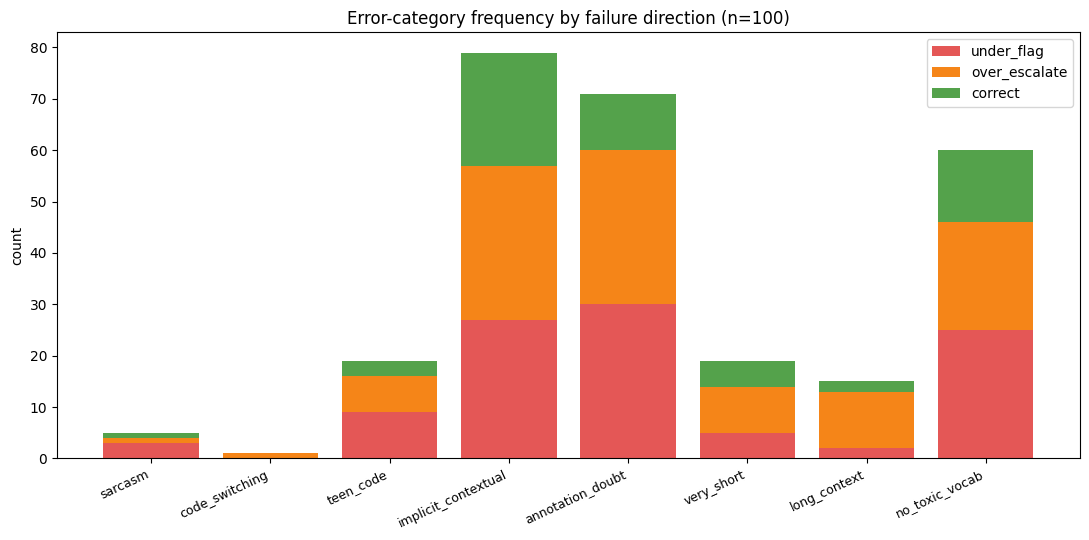


✓ saved → d:\Graduation Project\results\figures\32_error_categories.png


In [5]:
import matplotlib.pyplot as plt

PROGRESS_CSV = RESULTS_DIR / "manual_tagging_progress.csv"
assert PROGRESS_CSV.exists(), (
    f"No {PROGRESS_CSV.name} yet — tag cases in Part B (or the spreadsheet fallback) first."
)
tags = pd.read_csv(PROGRESS_CSV)
for c in CATEGORIES:
    if c not in tags.columns:
        tags[c] = 0
    tags[c] = tags[c].fillna(0).astype(int)
if "notes" not in tags.columns:
    tags["notes"] = ""
tags["notes"] = tags["notes"].fillna("").astype(str)

n_total  = len(tags)
n_tagged = int(((tags[CATEGORIES].sum(axis=1) > 0) | (tags["notes"].str.len() > 0)).sum())
print(f"Pool size: {n_total}  |  cases with ≥1 tag or note: {n_tagged}\n")

# Failure direction (severity ordinal CLEAN<OFFENSIVE<HATE).
def _direction(row):
    if row["phobert_pred"] == row["true_label"]:
        return "correct"
    return "under_flag" if row["phobert_pred"] < row["true_label"] else "over_escalate"
tags["fail_dir"] = tags.apply(_direction, axis=1)

def _len_bucket(n):
    if n <= 3:  return "very short [1-3]"
    if n <= 7:  return "short [4-7]"
    if n <= 15: return "medium [8-15]"
    if n <= 30: return "long [16-30]"
    return "very long [31+]"
tags["len_bucket"] = tags["length"].apply(_len_bucket)

# (1) Category frequency.
freq = pd.DataFrame({
    "category": CATEGORIES,
    "count":    [int(tags[c].sum()) for c in CATEGORIES],
})
freq["pct_of_pool"] = 100 * freq["count"] / n_total
print("Category frequency:")
print(freq.to_string(index=False, formatters={"pct_of_pool": "{:.1f}%".format}))

# (2) category × failure direction.
print("\nCategory × failure direction (counts):")
ct_dir = pd.DataFrame({c: tags.groupby("fail_dir")[c].sum() for c in CATEGORIES}).T.fillna(0).astype(int)
print(ct_dir.to_string())

# Bar chart of category frequency, split by failure direction.
fig, ax = plt.subplots(figsize=(11, 5.5))
dirs = ["under_flag", "over_escalate", "correct"]
colors = {"under_flag": "#E45756", "over_escalate": "#F58518", "correct": "#54A24B"}
bottom = np.zeros(len(CATEGORIES))
for d in dirs:
    vals = np.array([int(ct_dir.loc[c, d]) if d in ct_dir.columns else 0 for c in CATEGORIES], dtype=float)
    ax.bar(CATEGORIES, vals, bottom=bottom, label=d, color=colors[d])
    bottom += vals
ax.set_ylabel("count"); ax.set_title(f"Error-category frequency by failure direction (n={n_total})")
ax.set_xticklabels(CATEGORIES, rotation=25, ha="right", fontsize=9)
ax.legend()
plt.tight_layout()
fig_path = ROOT / "results" / "figures" / "32_error_categories.png"
fig.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"\n✓ saved → {fig_path}")


In [6]:
# (3) Which categories dominate the universal-failure subset D?
inD = tags["source_subset"] == "D_all_wrong"
print(f"Subset D (all-wrong) tagged cases: {int(inD.sum())}")
if inD.sum():
    dcat = pd.DataFrame({
        "category": CATEGORIES,
        "pct_in_D": [100 * tags.loc[inD, c].mean() for c in CATEGORIES],
    }).sort_values("pct_in_D", ascending=False)
    print(dcat.to_string(index=False, formatters={"pct_in_D": "{:.1f}%".format}))

# (4) code-switching concentration in OFFENSIVE→CLEAN.
off_to_clean = (tags["true_label"] == 1) & (tags["phobert_pred"] == 0)
if off_to_clean.sum():
    cs_rate = tags.loc[off_to_clean, "code_switching"].mean()
    ntv_rate = tags.loc[off_to_clean, "no_toxic_vocab"].mean()
    print(f"\nIn OFFENSIVE→CLEAN failures (n={int(off_to_clean.sum())}): "
          f"code_switching={cs_rate*100:.0f}%, no_toxic_vocab={ntv_rate*100:.0f}%")

# Per-category representative examples → markdown.
ex_lines = ["# Error-category examples (Week 5 Phase 2)", "",
            "_Auto-generated by `05b_qualitative_tagging.ipynb` from "
            "`manual_tagging_progress.csv`._", ""]
for c in CATEGORIES:
    sub = tags[tags[c] == 1]
    ex_lines.append(f"## {c}  (n={len(sub)})")
    ex_lines.append("")
    if len(sub) == 0:
        ex_lines.append("_no cases tagged_")
        ex_lines.append("")
        continue
    for _, r in sub.head(5).iterrows():
        note = f" — _{r['notes']}_" if str(r.get("notes", "")).strip() else ""
        ex_lines.append(f"- [{r['true_name']} → PhoBERT:{LABEL_MAP[int(r['phobert_pred'])]}] "
                        f"`{str(r['text'])[:140]}`{note}")
    ex_lines.append("")

ex_path = REPORT_DIR / "error_categories_examples.md"
ex_path.write_text("\n".join(ex_lines) + "\n", encoding="utf-8")
print(f"\n✓ saved → {ex_path}")


Subset D (all-wrong) tagged cases: 30
           category pct_in_D
   annotation_doubt    83.3%
     no_toxic_vocab    63.3%
implicit_contextual    60.0%
          teen_code    26.7%
         very_short    20.0%
            sarcasm    10.0%
       long_context     6.7%
     code_switching     0.0%

In OFFENSIVE→CLEAN failures (n=11): code_switching=0%, no_toxic_vocab=73%

✓ saved → d:\Graduation Project\report\error_categories_examples.md


In [7]:
# Synthesis → report/week5_qualitative_findings.md
lines = []
lines.append("# Week 5 Phase 2: Qualitative Error Findings")
lines.append("")
lines.append(f"_Auto-generated from {n_tagged}/{n_total} tagged cases "
             f"(`manual_tagging_progress.csv`)._")
lines.append("")

lines.append("## Category frequency")
lines.append("")
lines.append("| Category | Count | % of pool |")
lines.append("|---|---|---|")
for _, r in freq.sort_values("count", ascending=False).iterrows():
    lines.append(f"| {r['category']} | {int(r['count'])} | {r['pct_of_pool']:.1f}% |")
lines.append("")

# Subset-D dominance
if inD.sum():
    top_d = dcat.iloc[0]
    lines.append("## Universal failures (subset D)")
    lines.append("")
    lines.append(f"- {int(inD.sum())} tagged cases. Most common category: "
                 f"**{top_d['category']}** ({top_d['pct_in_D']:.0f}% of D).")
    lines.append(f"- Top-3 in D: " + ", ".join(
        f"{r['category']} ({r['pct_in_D']:.0f}%)" for _, r in dcat.head(3).iterrows()))
    lines.append("")

# Failure-direction crosstab
lines.append("## Category × failure direction")
lines.append("")
lines.append("| Category | under_flag | over_escalate | correct |")
lines.append("|---|---|---|---|")
for c in CATEGORIES:
    uf = int(ct_dir.loc[c, "under_flag"]) if "under_flag" in ct_dir.columns else 0
    oe = int(ct_dir.loc[c, "over_escalate"]) if "over_escalate" in ct_dir.columns else 0
    co = int(ct_dir.loc[c, "correct"]) if "correct" in ct_dir.columns else 0
    lines.append(f"| {c} | {uf} | {oe} | {co} |")
lines.append("")

# Findings cross-check
lines.append("## Phase-1 findings cross-check")
lines.append("")
if off_to_clean.sum():
    lines.append(f"- **F5 (subtle toxicity)**: in OFFENSIVE→CLEAN failures, "
                 f"`no_toxic_vocab` = {tags.loc[off_to_clean,'no_toxic_vocab'].mean()*100:.0f}%, "
                 f"`code_switching` = {tags.loc[off_to_clean,'code_switching'].mean()*100:.0f}%.")
long_ctx = tags[tags["long_context"] == 1]
if len(long_ctx):
    lc_off_underflag = ((long_ctx["true_label"] == 1) & (long_ctx["phobert_pred"] == 0)).sum()
    lines.append(f"- **F2 (long-context OFFENSIVE crash)**: of {len(long_ctx)} long-context cases, "
                 f"{int(lc_off_underflag)} are OFFENSIVE under-flagged to CLEAN.")
ad = int(tags["annotation_doubt"].sum())
lines.append(f"- **Annotation doubt**: {ad} cases ({100*ad/n_total:.0f}% of pool) flagged as "
             f"label-questionable — supports the OFFENSIVE annotation-ambiguity hypothesis from Week 4.")
lines.append("")

lines.append("## Recommendations")
lines.append("")
lines.append("- If `no_toxic_vocab` + `implicit_contextual` dominate OFFENSIVE→CLEAN: the model "
             "lacks targeted/implicit-toxicity signal — consider data augmentation with implicit "
             "examples or a context-aware threshold.")
lines.append("- If `annotation_doubt` is high: a re-annotation pass (or soft labels) is the "
             "highest-leverage fix — caps the achievable ceiling otherwise.")
lines.append("- If `teen_code` / `code_switching` are frequent: extend preprocessing normalisation "
             "(teencode dictionary) and/or consider a multilingual checkpoint.")

out = REPORT_DIR / "week5_qualitative_findings.md"
out.write_text("\n".join(lines) + "\n", encoding="utf-8")
print(f"✓ saved → {out}\n")
print(out.read_text(encoding="utf-8"))


✓ saved → d:\Graduation Project\report\week5_qualitative_findings.md

# Week 5 Phase 2: Qualitative Error Findings

_Auto-generated from 98/100 tagged cases (`manual_tagging_progress.csv`)._

## Category frequency

| Category | Count | % of pool |
|---|---|---|
| implicit_contextual | 79 | 79.0% |
| annotation_doubt | 71 | 71.0% |
| no_toxic_vocab | 60 | 60.0% |
| teen_code | 19 | 19.0% |
| very_short | 19 | 19.0% |
| long_context | 15 | 15.0% |
| sarcasm | 5 | 5.0% |
| code_switching | 1 | 1.0% |

## Universal failures (subset D)

- 30 tagged cases. Most common category: **annotation_doubt** (83% of D).
- Top-3 in D: annotation_doubt (83%), no_toxic_vocab (63%), implicit_contextual (60%)

## Category × failure direction

| Category | under_flag | over_escalate | correct |
|---|---|---|---|
| sarcasm | 3 | 1 | 1 |
| code_switching | 0 | 1 | 0 |
| teen_code | 9 | 7 | 3 |
| implicit_contextual | 27 | 30 | 22 |
| annotation_doubt | 30 | 30 | 11 |
| very_short | 5 | 9 | 5 |
| long_context 